In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Advertising.csv')

In [3]:
# ilk beş satırımızı görelim
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# sütunlarımızı görelim
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [5]:
# verisetimiz inceleyelim boş satırlar var mı
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
X = df[['TV', 'Radio', 'Newspaper']]
y= df[['Sales']]

In [8]:
X_train,X_test, y_train, y_test =train_test_split(X, y, test_size=0.2,random_state=42)

In [9]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [10]:
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Ortalama Kare Hatası (MSE): {mse:.2f}")
print(f"R-kare (R2) Skoru: {r2:.2f}")

Ortalama Kare Hatası (MSE): 3.17
R-kare (R2) Skoru: 0.90


In [11]:
# Sabit değeri (intercept) güvenli bir şekilde içindeki sayıya çevirelim
sabit_deger = model.intercept_.item() if hasattr(model.intercept_, 'item') else model.intercept_
print(f"Sabit Değer (Intercept): {sabit_deger:.2f}")

# Katsayıları (coef) düzleştirerek (flatten) güvenli bir şekilde tabloya alalım
katsayilar = pd.DataFrame(model.coef_.flatten(), index=X.columns, columns=['Katsayı (Etki)'])
print("\nReklam Kanallarının Satışlara Etkisi:")
print(katsayilar)

Sabit Değer (Intercept): 2.98

Reklam Kanallarının Satışlara Etkisi:
           Katsayı (Etki)
TV               0.044730
Radio            0.189195
Newspaper        0.002761


In [12]:
# Gazete (Newspaper) sütununu veri setinden çıkarıyoruz
X_yeni = X.drop('Newspaper', axis=1)

# Şimdi modeli sadece TV ve Radyo ile tekrar eğitelim
X_train_yeni, X_test_yeni, y_train, y_test = train_test_split(X_yeni, y, test_size=0.2, random_state=42)

model_yeni = LinearRegression()
model_yeni.fit(X_train_yeni, y_train)

# Yeni başarı skoru
y_pred_yeni = model_yeni.predict(X_test_yeni)
print(f"Yeni R2 Skoru: {r2_score(y_test, y_pred_yeni):.4f}")

Yeni R2 Skoru: 0.9006


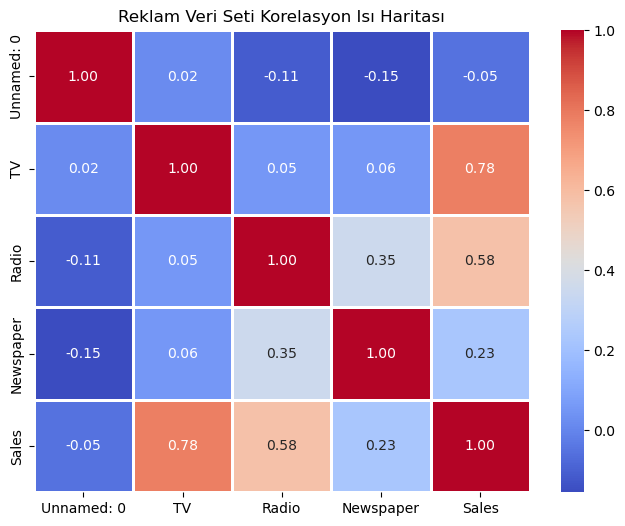

In [13]:
korelasyon_matrisi = df.corr()

# Isı haritası için bir tuval (figure) oluştur
plt.figure(figsize=(8, 6))

# Heatmap'i çiz (annot=True ile kutuların içine sayıları yazdırıyoruz)
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

plt.title('Reklam Veri Seti Korelasyon Isı Haritası')
plt.show()

In [14]:
#  "Elde edilen $R^2$ skoruna göre modelimiz %90 başarılıdır. Bütçenin gazeteden alınıp, getirisi en yüksek olan radyoya ve TV'ye kaydırılması önerilmektedir.